# Customer Segmentation Using K-Means Clustering

## Project Overview

This project applies K-Means clustering to customer spending data.

The analysis includes:
- data exploration
- clustering analysis
- cluster visualization
- customer segmentation
- insight generation

## Objectives

- Understand unsupervised machine learning
- Apply K-Means clustering
- Visualize customer clusters
- Identify customer behavior patterns

In [23]:
# IMPORT REQUIRED LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [24]:
# LOAD DATASET
# Read Dataset
df = pd.read_csv("../data/customer_data.csv")

# Display first 5 rows
df.head()

,CustomerID,AnnualIncome,SpendingScore
0,1,15,39
1,2,15,81
2,3,16,6
3,4,16,77
4,5,17,40


In [25]:
# DATASET INFORMATION & STRUCTURE
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(40, 3)

Column Names:
Index(['CustomerID', 'AnnualIncome', 'SpendingScore'], dtype='str')

Data Types:
CustomerID       int64
AnnualIncome     int64
SpendingScore    int64
dtype: object


In [26]:
# SUMMARY STATISTICS
df.describe()

,CustomerID,AnnualIncome,SpendingScore
count,40.000000,40.000000,40.000000
mean,20.500000,24.850000,49.275000
std,11.690452,6.375233,32.643362
min,1.000000,15.000000,3.000000
25%,10.750000,19.750000,14.750000
50%,20.500000,24.500000,50.500000
75%,30.250000,29.250000,77.000000
max,40.000000,37.000000,99.000000


In [27]:
# CHECK MISSING VALUES
df.isnull().sum()

CustomerID       0
AnnualIncome     0
SpendingScore    0
dtype: int64

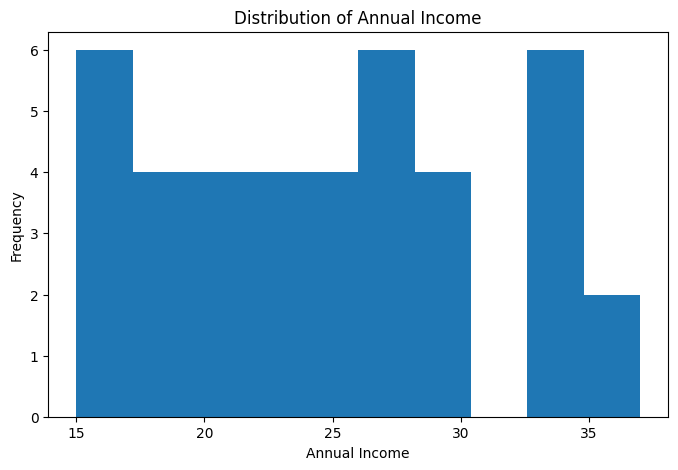

In [28]:
# VISUALIZE FEATURE DISTRIBUTION
plt.figure(figsize=(8,5))

plt.hist(df['AnnualIncome'], bins=10)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

# Save visualization
plt.savefig("../visuals/feature_distribution.png")

plt.show()

In [29]:
# PREPARE DATA FOR CLUSTERING
X = df[['AnnualIncome', 'SpendingScore']]

X.head()

,AnnualIncome,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


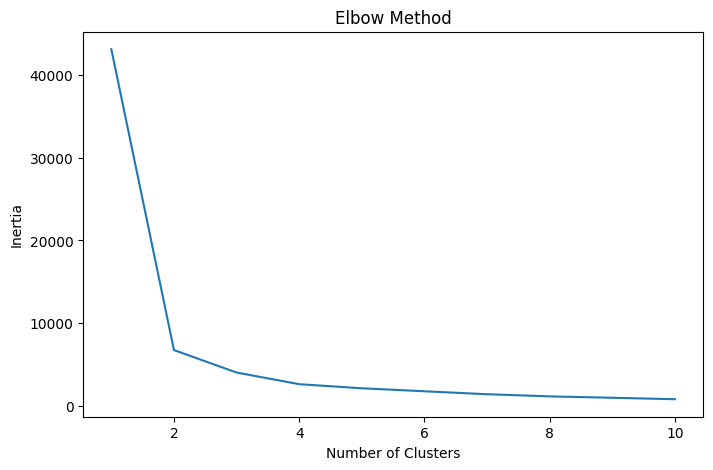

In [30]:
# FIND OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD)
inertia_values = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertia_values.append(kmeans.inertia_)

# Plot elbow method
plt.figure(figsize=(8,5))

plt.plot(range(1, 11), inertia_values)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

# Save visualization
plt.savefig("../visuals/elbow_method.png")

plt.show()

In [31]:
# APPLY K-MEANS CLUSTERING
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Generate cluster labels
df['Cluster'] = kmeans.fit_predict(X)

# Display updated dataset
df.head()

,CustomerID,AnnualIncome,SpendingScore,Cluster
0,1,15,39,4
1,2,15,81,2
2,3,16,6,1
3,4,16,77,2
4,5,17,40,4


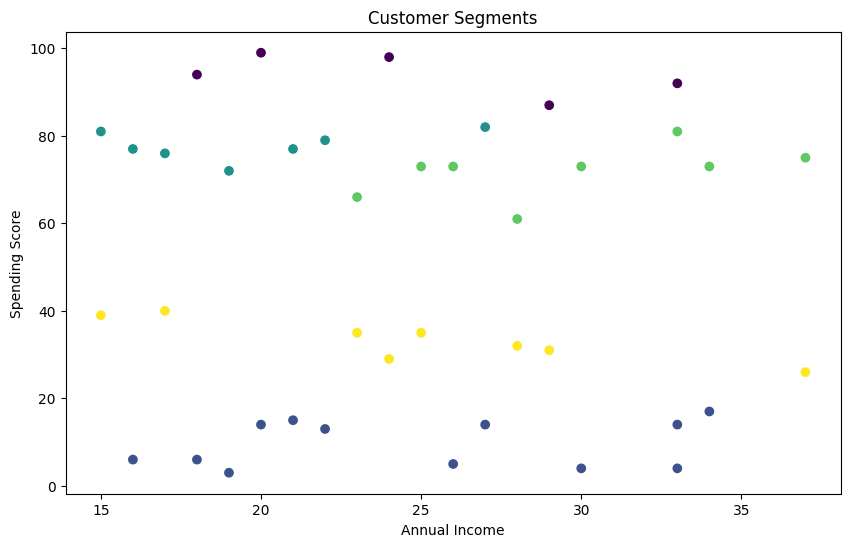

In [32]:
# VISUALIZE CLUSTERS
plt.figure(figsize=(10,6))

plt.scatter(
    df['AnnualIncome'],
    df['SpendingScore'],
    c=df['Cluster']
)

plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

# Save visualization
plt.savefig("../visuals/clusters.png")

plt.show()

In [33]:
X = df[["AnnualIncome", "SpendingScore"]]

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

# Add human-readable segment labels
segment_map = {
    0: "Budget Savers",
    1: "High Earners, Low Spend",
    2: "Standard Customers",
    3: "High Earners, High Spend",
    4: "Low Earners, High Spend"
}
df["Segment"] = df["Cluster"].map(segment_map)

# Add cluster centroids as reference columns
centers = kmeans.cluster_centers_
df["Cluster_Income_Center"]  = df["Cluster"].apply(lambda c: round(centers[c][0], 2))
df["Cluster_Spending_Center"] = df["Cluster"].apply(lambda c: round(centers[c][1], 2))

df.to_csv("../data/customer_clusters_powerbi.csv", index=False)
print("Exported: customer_clusters_powerbi.csv")

Exported: customer_clusters_powerbi.csv


# Key Insights

## Clustering Findings

- Customers were successfully segmented into 5 clusters.
- Different groups display different spending behaviors.
- Some customers have high income but low spending scores.
- Other customers demonstrate high spending behavior despite moderate income levels.

## Business Value

K-Means clustering can help businesses:

- identify customer segments
- improve marketing strategies
- personalize customer experiences
- target high-value customers
- improve business decision-making

## Machine Learning Insights

This project demonstrates:

- unsupervised learning
- clustering algorithms
- data visualization
- customer segmentation
- pattern recognition